In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score
)
import xgboost as xgb
import lightgbm as lgb
import pickle

In [12]:
df=pd.read_csv("train(1).csv")

In [13]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [14]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [15]:
df.shape

(200000, 202)

In [16]:

df.isnull().sum().sum()

np.int64(0)

In [17]:
print(df["target"].value_counts())

print(df["target"].value_counts(normalize=True) * 100)

feature_cols = [col for col in df.columns if col.startswith("var_")]

print("Total Features:", len(feature_cols))

print("Min:", df[feature_cols].min().min())

print("Max:", df[feature_cols].max().max())

print("Mean:", df[feature_cols].mean().mean())

print("Std:", df[feature_cols].std().mean())

print("Duplicate Rows:", df.duplicated(subset=feature_cols).sum())

target
0    179902
1     20098
Name: count, dtype: int64
target
0    89.951
1    10.049
Name: proportion, dtype: float64
Total Features: 200
Min: -90.2525
Max: 74.0321
Mean: 6.7674488530675
Std: 4.494649721046881
Duplicate Rows: 0


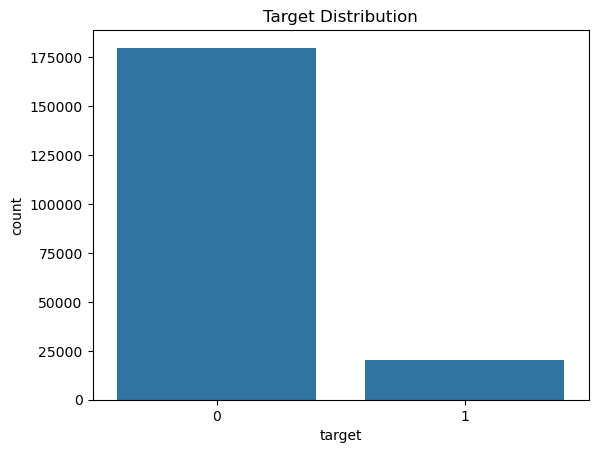

In [18]:
sns.countplot(x="target",data =df)
plt.title("Target Distribution")
plt.show()

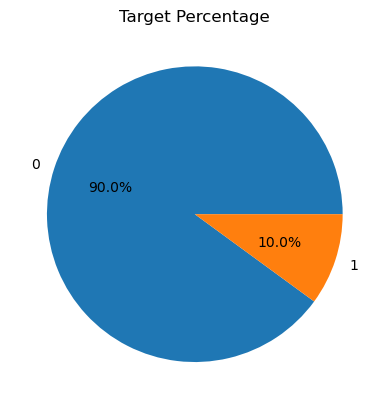

In [19]:
df["target"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Target Percentage")
plt.ylabel("")
plt.show()

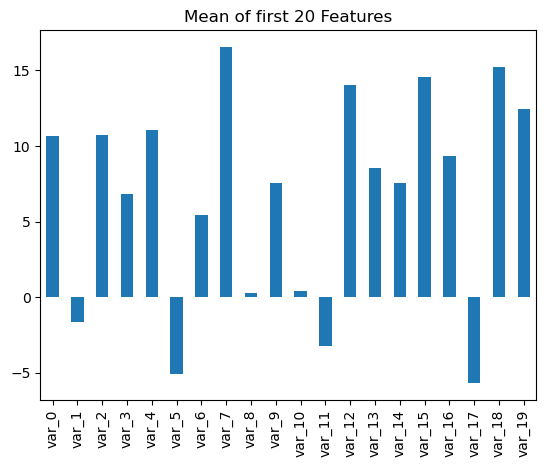

In [20]:
features_cols =[col for col in df.columns if col.startswith("var")]

df[features_cols[:20]].mean().plot(kind="bar")
plt.title("Mean of first 20 Features")
plt.show()

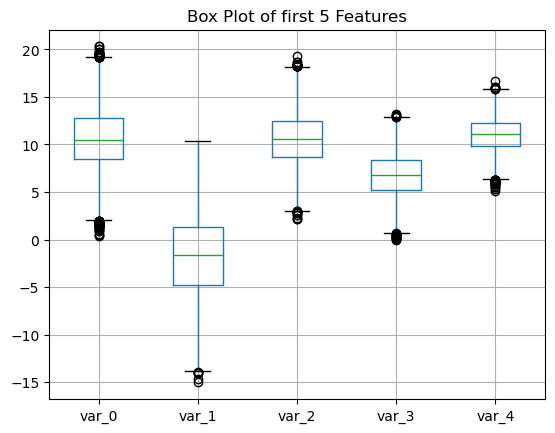

In [21]:
df[features_cols[:5]].boxplot()
plt.title("Box Plot of first 5 Features")
plt.show()

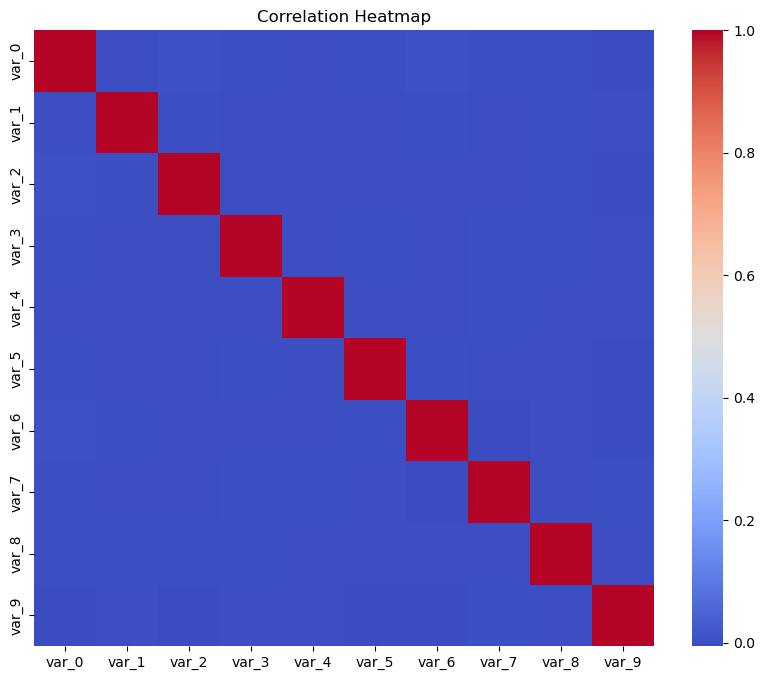

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[features_cols[:10]].corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

X =df.drop(['ID_code', 'target'], axis=1)
y= df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42, stratify=y
) 
print("Training Date:", X_train.shape)
print("Testing Date:", X_test.shape)

Training Date: (160000, 200)
Testing Date: (40000, 200)


In [24]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features Scaling Completed")

Features Scaling Completed


In [18]:
print("Logistic Regression")

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy  :", accuracy_score(y_test,y_pred_lr))
print("Precision :", precision_score(y_test,y_pred_lr))
print("Recall    :", recall_score(y_test,y_pred_lr))
print("F1 Score  :", f1_score(y_test,y_pred_lr))
print("ROC AUC   :", roc_auc_score(y_test,y_prob_lr))


Logistic Regression
Accuracy  : 0.913425
Precision : 0.6826229508196722
Recall    : 0.258955223880597
F1 Score  : 0.37547339945897207
ROC AUC   : 0.8598716810610648


In [19]:
print("Random Forest")

rf_model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)
print("training started")
rf_model.fit(X_train_scaled, y_train)
print("training completed")

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy  :", accuracy_score(y_test,y_pred_rf))
print("Precision :", precision_score(y_test,y_pred_rf))
print("Recall    :", recall_score(y_test,y_pred_rf))
print("F1 Score  :", f1_score(y_test,y_pred_rf))
print("ROC AUC   :", roc_auc_score(y_test,y_prob_rf))

Random Forest
training started
training completed
Accuracy  : 0.899675
Precision : 0.5289256198347108
Recall    : 0.015920398009950248
F1 Score  : 0.03091040811398213
ROC AUC   : 0.6991479442697575


In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Gradient Boosting training started...")

gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting training completed.")

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, zero_division=0)
gb_recall = recall_score(y_test, y_pred_gb, zero_division=0)
gb_f1 = f1_score(y_test, y_pred_gb, zero_division=0)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print("\nGradient Boosting Performance")
print("--------------------------------")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC AUC  : {gb_auc:.4f}")

Gradient Boosting training started...
Gradient Boosting training completed.

Gradient Boosting Performance
--------------------------------
Accuracy : 0.8996
Precision: 1.0000
Recall   : 0.0007
F1 Score : 0.0015
ROC AUC  : 0.7834


In [26]:
print("XGBoost")

xgb_model = xgb.XGBClassifier(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy  :", accuracy_score(y_test,y_pred_xgb))
print("Precision :", precision_score(y_test,y_pred_xgb))
print("Recall    :", recall_score(y_test,y_pred_xgb))
print("F1 Score  :", f1_score(y_test,y_pred_xgb))
print("ROC AUC   :", roc_auc_score(y_test,y_prob_xgb))

XGBoost
Accuracy  : 0.913225
Precision : 0.6833667334669339
Recall    : 0.2544776119402985
F1 Score  : 0.3708537248504622
ROC AUC   : 0.8563926234585825


In [28]:
print("lightGBM")

lgb_model = lgb.LGBMClassifier(random_state=42)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]

print("Accuracy  :", accuracy_score(y_test,y_pred_lgb))
print("Precision :", precision_score(y_test,y_pred_lgb))
print("Recall    :", recall_score(y_test,y_pred_lgb))
print("F1 Score  :", f1_score(y_test,y_pred_lgb))
print("ROC AUC   :", roc_auc_score(y_test,y_prob_lgb))

lightGBM
[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.424666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100487 -> initscore=-2.191820
[LightGBM] [Info] Start training from score -2.191820
Accuracy  : 0.906825
Precision : 0.85995085995086
Recall    : 0.08706467661691543
F1 Score  : 0.1581206234470296
ROC AUC   : 0.865231838307075


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

print("Models created successfully:")
for name in models:
    print("-", name)

Models created successfully:
- Logistic Regression
- Random Forest


In [29]:
comparison = pd.DataFrame(results)

# Sort models by ROC-AUC score
comparison = comparison.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

print("Model Comparison")
display(comparison)


Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.913325,0.681788,0.25796,0.374301,0.857892


In [32]:
best_model = comparison.iloc[0]

print("\nBest Model")
print("______")
print("Model Name :", best_model["Model"])
print("ROC AUC    :", round(best_model["ROC AUC"],4))


Best Model
______
Model Name : Logistic Regression
ROC AUC    : 0.8579


In [38]:
print("\nBest Model Performance")
print("----------------------")

print("Model    :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall   :", round(best_model["Recall"], 4))
print("F1 Score :", round(best_model["F1 Score"], 4))
print("ROC AUC  :", round(best_model["ROC AUC"], 4))


Best Model Performance
----------------------
Model    : Logistic Regression
Accuracy : 0.9133
Precision: 0.6818
Recall   : 0.258
F1 Score : 0.3743
ROC AUC  : 0.8579


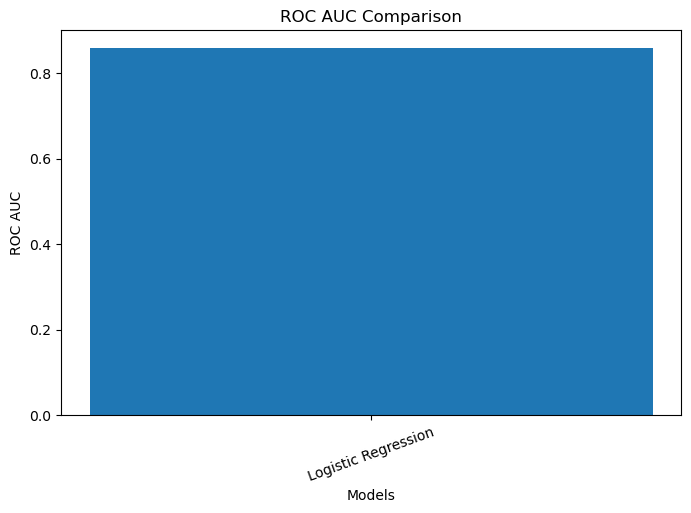

In [39]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["ROC AUC"])

plt.title("ROC AUC Comparison")
plt.xlabel("Models")
plt.ylabel("ROC AUC")

plt.xticks(rotation=20)

plt.show()

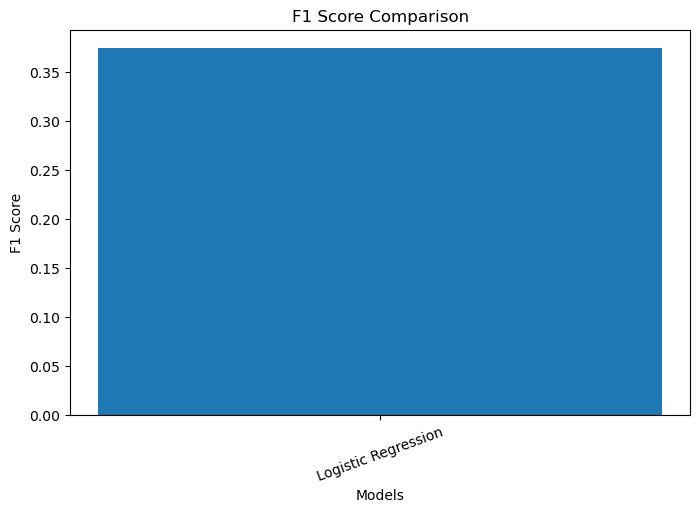

In [41]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1 Score"])

plt.title("F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

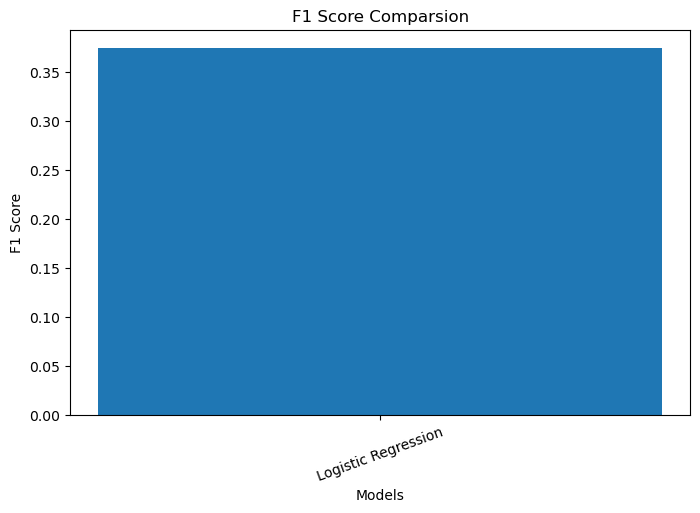

In [42]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1 Score"])

plt.title("F1 Score Comparsion")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

In [43]:
import os
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

In [49]:
best_model_name = comparison.loc[0, "Model"]

# Get the trained model
best_model = models[best_model_name]

# Generate predictions
best_y_pred = best_model.predict(X_test)

# Generate prediction probabilities
best_y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("DETAILED ANALYSIS OF BEST MODEL")
print("=" * 50)

print("\nBest Model :", best_model_name)
print("Predictions generated successfully.")

DETAILED ANALYSIS OF BEST MODEL

Best Model : Logistic Regression
Predictions generated successfully.


In [51]:
# Model Performance

best_accuracy = accuracy_score(y_test, best_y_pred)
best_precision = precision_score(
    y_test, best_y_pred, zero_division=0
)
best_recall = recall_score(
    y_test, best_y_pred, zero_division=0
)
best_f1 = f1_score(
    y_test, best_y_pred, zero_division=0
)
best_roc_auc = roc_auc_score(
    y_test, best_y_pred_proba
)

print("\nClassification Metrics")
print("-" * 30)
print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")
print(f"ROC AUC  : {best_roc_auc:.4f}")


Classification Metrics
------------------------------
Accuracy : 0.9133
Precision: 0.6818
Recall   : 0.2580
F1 Score : 0.3743
ROC AUC  : 0.8579


In [52]:
# Classification Report

print("\nClassification Report\n")

print(classification_report(
    y_test,
    best_y_pred,
    target_names=["No Transaction", "Transaction"]
))



Classification Report

                precision    recall  f1-score   support

No Transaction       0.92      0.99      0.95     35980
   Transaction       0.68      0.26      0.37      4020

      accuracy                           0.91     40000
     macro avg       0.80      0.62      0.66     40000
  weighted avg       0.90      0.91      0.90     40000



In [53]:
# Confusion Matrix Values

cm = confusion_matrix(y_test, best_y_pred)

print("\nConfusion Matrix")

print(f"True Negative  : {cm[0,0]}")
print(f"False Positive : {cm[0,1]}")
print(f"False Negative : {cm[1,0]}")
print(f"True Positive  : {cm[1,1]}")



Confusion Matrix
True Negative  : 35496
False Positive : 484
False Negative : 2983
True Positive  : 1037


In [60]:
# Feature Importance Analysis

import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_

elif hasattr(best_model, "coef_"):
    importance_values = abs(best_model.coef_[0])

else:
    raise ValueError(
        "The selected model does not support feature importance analysis."
    )
    
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display Top 15 features
print("Top 15 Important Features")
display(feature_importance.head(15))

Top 15 Important Features


,Feature,Importance
0,var_91,1.214035
1,var_68,1.154987
2,var_12,0.733375
3,var_148,0.687205
4,var_133,0.472909
5,var_71,0.446170
6,var_166,0.435216
7,var_125,0.431557
8,var_169,0.358825
9,var_25,0.348279


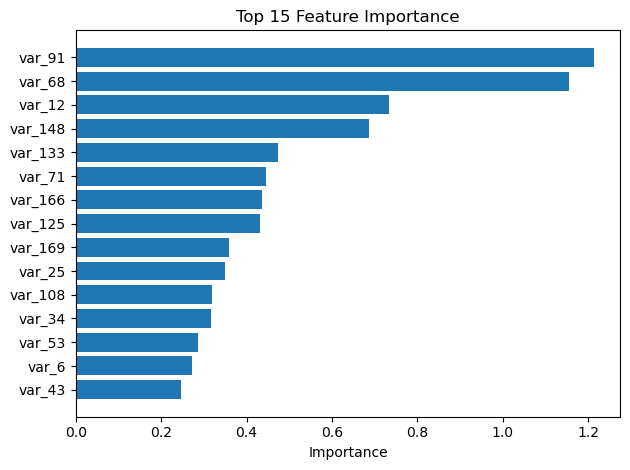

In [62]:
    plt.barh(
        feature_importance["Feature"][:15],
        feature_importance["Importance"][:15]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Importance")
    plt.title("Top 15 Feature Importance")

    plt.tight_layout()

    plt.savefig(f"{output_path}/Feature_importance.png", dpi=300)

    plt.show()



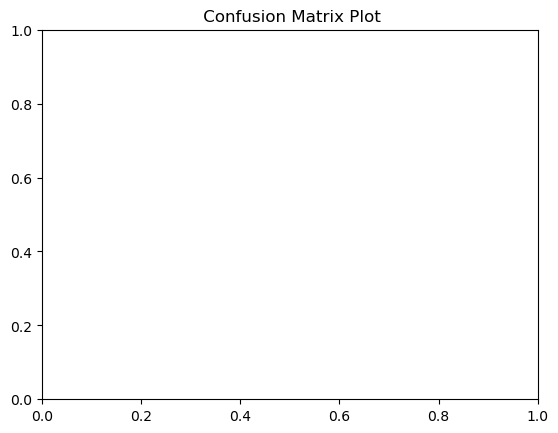

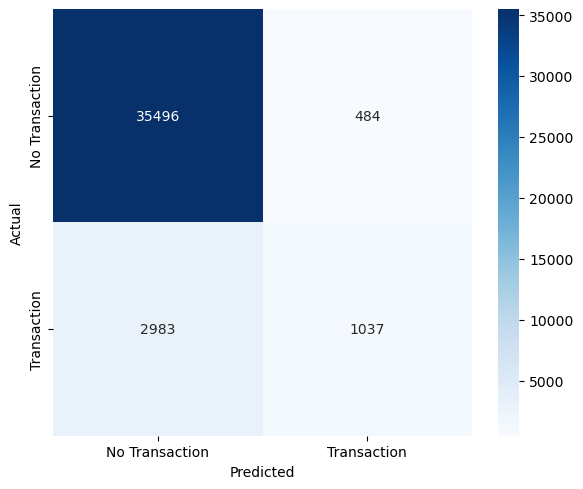

In [65]:
plt.title(" Confusion Matrix Plot")

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Transaction","Transaction"],
    yticklabels=["No Transaction","Transaction"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(f"{output_path}/Confusion_Matrix.png", dpi=300)

plt.show()


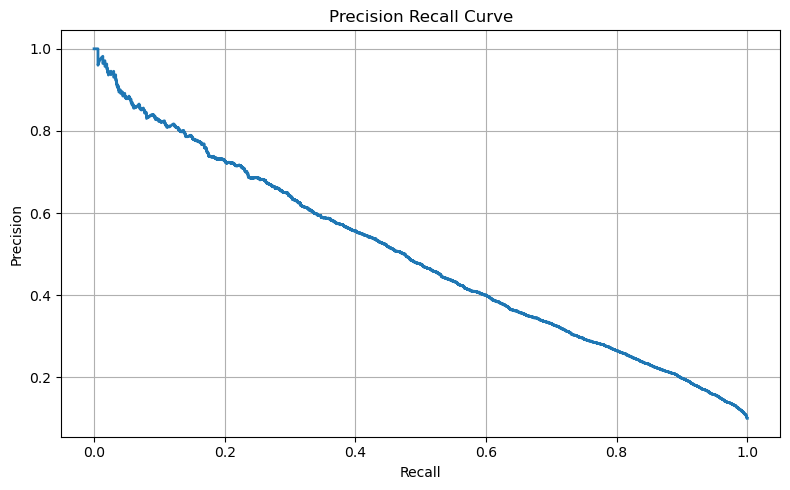


Analysis Completed Successfully.


In [66]:
# Precision Recall Curve

precision, recall, _ = precision_recall_curve(
    y_test,
    best_y_pred_proba
)

plt.figure(figsize=(8,5))

plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.grid(True)

plt.tight_layout()

plt.savefig(f"{output_path}/Precision_Recall_Curve.png", dpi=300)

plt.show()

print("\nAnalysis Completed Successfully.")

In [67]:
import os
import joblib

In [68]:
output_path = "output"
os.makedirs(output_path, exist_ok=True)

In [69]:
joblib.dump(scaler, f"{output_path}/best_model.pkl")
print(" BEST MODEL SAVED")

 BEST MODEL SAVED


In [71]:
# Save each trained model
for name, model in models.items():
    file_name = name.lower().replace(" ", "_")
    model_path = os.path.join(
        output_path,
        f"model_{file_name}.pkl"
    )
    
    # Save model
    joblib.dump(model, model_path)

    print(f"Saved: {model_path}")

print("\nAll models saved successfully.")

Saved: output\model_logistic_regression.pkl
Saved: output\model_random_forest.pkl

All models saved successfully.


In [76]:
comparison_df = pd.DataFrame(results)

# Sort models by ROC AUC
comparison_df = comparison_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

# Save comparison results
comparison_file = os.path.join(
    output_path,
    "model_comparison_results.csv"
)

comparison_df.to_csv(
    comparison_file,
    index=False
)

print("Model Comparison Saved Successfully!")
print(f"File: {comparison_file}")

# Display results
display(comparison_df)

Model Comparison Saved Successfully!
File: output\model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.913325,0.681788,0.25796,0.374301,0.857892


In [80]:
if hasattr(best_model, "features_importance_"):

    feature_importance.to_csv(
        f"{output_path}/feature_importance.csv",
        index=False
    )

    print(" Feature Important Saved")

Project Summary

* Developed a Machine Learning model to predict customer transactions.
* Performed data cleaning, preprocessing, and feature scaling.
* Conducted Exploratory Data Analysis (EDA) to understand the dataset.
* Trained and compared multiple classification models.
* Evaluated models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
* Selected the best-performing model based on evaluation metrics.
* Analyzed model performance using a Confusion Matrix and Classification Report.
* Generated ROC Curve, Precision-Recall Curve, and Feature Importance visualizations.
* Saved the trained model, scaler, and project results for future predictions.
* Successfully completed an end-to-end Machine Learning pipeline for customer transaction prediction.

# Final Conclusion

This project developed a machine learning classification model for customer transaction prediction.

### Key Achievements

- Performed data preprocessing and feature scaling.
- Conducted Exploratory Data Analysis (EDA).
- Trained and compared multiple classification models.
- Evaluated models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Identified the best-performing model.
- Analyzed feature importance.
- Generated classification and ROC-based visualizations.
- Saved the trained model and supporting project files.
- Demonstrated prediction on unseen customer data.

### Business Value

The developed model can support data-driven customer transaction analysis and help organizations identify transaction patterns and improve decision-making.

### Future Improvements

- Hyperparameter tuning.
- Cross-validation.
- Model explainability using SHAP.
- Deployment using Streamlit or Flask.
- Real-time transaction prediction.
- Continuous model monitoring.